# Model Training

1.1 Importing the dataset and the required packages

Import pandas, numpy, matplotlib, seaborn, Scikit-Learn, warnings library.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Performance metric
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score,
    confusion_matrix,classification_report)

# To handle imbalanced data

from imblearn.over_sampling import SMOTE

In [3]:
data=pd.read_csv("Telco_customer_churn.csv")
data.head(1)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer


In [4]:
# Dropping the columns which are not used for prediction
data.drop(columns=['CustomerID','Count','Country','State','Lat Long','Churn Label','Churn Score','Churn Reason','CLTV'],inplace=True)
data.head(1)

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


defining the dropping variables

In [5]:
data['Total Charges']=pd.to_numeric(data['Total Charges'],errors='coerce')
data = data.dropna(subset=['Total Charges'])

In [6]:
# Independent and dependent (target) 
X=data.drop(columns=['Churn Value'])
y=data['Churn Value']

In [22]:
# Replace 'target_column' with the name of your label column
data['Churn Value'].value_counts(normalize=True) * 100


Churn Value
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [7]:
print(X.shape)
print(y.shape)

(7032, 23)
(7032,)


In [8]:
# Separating columns based on numerical and categorical type.
Cat_col=X.select_dtypes(include='object').columns
num_col=X.select_dtypes(exclude='object').columns

In [9]:
print(Cat_col)
print(num_col)

Index(['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'],
      dtype='object')
Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges'],
      dtype='object')


In [10]:
print("Categories in 'City' variable:     ",end=" " )
print(data['City'].unique())

print("Categories in 'Gender' variable:  ",end=" ")
print(data['Gender'].unique())

print("Categories in 'Senior Citizen' variable:  ",end=" ")
print(data['Senior Citizen'].unique())

print("Categories in'Partner' variable:",end=" " )
print(data['Partner'].unique())

print("Categories in 'Dependents' variable:     ",end=" " )
print(data['Dependents'].unique())

print("Categories in 'Phone Service' variable:     ",end=" " )
print(data['Phone Service'].unique())

print("Categories in 'Multiple Lines' variable:     ",end=" " )
print(data['Multiple Lines'].unique())

print("Categories in 'Internet Service' variable:     ",end=" " )
print(data['Internet Service'].unique())

print("Categories in 'Online Security' variable:     ",end=" " )
print(data['Online Security'].unique())

print("Categories in 'Online Backup' variable:     ",end=" " )
print(data['Online Backup'].unique())

print("Categories in 'Device Protection' variable:     ",end=" " )
print(data['Device Protection'].unique())

print("Categories in 'Tech Support' variable:     ",end=" " )
print(data['Tech Support'].unique())

print("Categories in 'Streaming TV' variable:     ",end=" " )
print(data['Streaming TV'].unique())

print("Categories in 'Streaming Movies' variable:     ",end=" " )
print(data['Streaming Movies'].unique())

print("Categories in 'Payment Method' variable:     ",end=" " )
print(data['Payment Method'].unique())

print("Categories in 'Contract' variable:     ",end=" " )
print(data['Contract'].unique())

print("Categories in 'Paperless Billing' variable:     ",end=" " )
print(data['Paperless Billing'].unique())

Categories in 'City' variable:      ['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Tulelake'
 'Olympic Valley' 'Redcrest']
Categories in 'Gender' variable:   ['Male' 'Female']
Categories in 'Senior Citizen' variable:   ['No' 'Yes']
Categories in'Partner' variable: ['No' 'Yes']
Categories in 'Dependents' variable:      ['No' 'Yes']
Categories in 'Phone Service' variable:      ['Yes' 'No']
Categories in 'Multiple Lines' variable:      ['No' 'Yes' 'No phone service']
Categories in 'Internet Service' variable:      ['DSL' 'Fiber optic' 'No']
Categories in 'Online Security' variable:      ['Yes' 'No' 'No internet service']
Categories in 'Online Backup' variable:      ['Yes' 'No' 'No internet service']
Categories in 'Device Protection' variable:      ['No' 'Yes' 'No internet service']
Categories in 'Tech Support' variable:      ['No' 'Yes' 'No internet service']
Categories in 'Streaming TV' variable:      ['No' 'Yes' 'No internet service']
Categories in 'Streaming Movies' variable:   

In [11]:
binary_cols=['Gender','Senior Citizen','Partner','Dependents','Phone Service','Paperless Billing']
ordinal_cols=['Contract']
high_cardinality_cols = ['City']
nominal_cols=[col for col in Cat_col if col not in binary_cols+ordinal_cols+high_cardinality_cols]

In [12]:
print(binary_cols)
print(ordinal_cols)
print(nominal_cols)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']
['Contract']
['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Payment Method']


In [13]:
def binary_mapping(x):
    mapping={'Yes':1,"No":0,"Female":1,"Male":0}
    return x.apply(lambda col: col.map(mapping))

city_frequency=data['City'].value_counts().to_dict()
def frequency_encoding(x):
    x=x.copy()
    return x.apply(lambda col: col.map(city_frequency))
binary_transformer=FunctionTransformer(binary_mapping)

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()
ordinal_transformer = OrdinalEncoder(categories=[['Month-to-month','One year','Two year']])
city_transformer = FunctionTransformer(frequency_encoding)
preprocessor=ColumnTransformer(
    [
        ("StandardScaler",numeric_transformer,num_col),
        ("OrdinalEncoder",ordinal_transformer,ordinal_cols),
        ("OneHotEncoder",oh_transformer,nominal_cols),
        ("city_function",city_transformer,high_cardinality_cols,),
        ('binary', binary_transformer, binary_cols),

    ],
)

In [14]:
X=preprocessor.fit_transform(X)
X.shape

(7032, 42)

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((5625, 42), (1407, 42))

In [19]:
## Evaluation metrices after model training.
def evaluate_model(true, predicted):
    accuracy=accuracy_score(true, predicted)
    precision=precision_score(true, predicted)
    recall=recall_score(true, predicted)
    f1=f1_score(true, predicted)
    #roc=roc_auc_score(true, predicted)
    
    #confusion=confusion_matrix(true, predicted)
    #classification=classification_report(true, predicted)    
    return accuracy,precision,recall,f1

In [ ]:
models={
    "Logistic Regression":LogisticRegression(),
    "K-Neighbors Classifier":KNeighborsClassifier(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest Classifier":RandomForestClassifier(),
    "XGB Classifier": XGBClassifier(),
    "Gradient Booster":GradientBoostingClassifier(),
    "CatBoosting":CatBoostClassifier(verbose=False),
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    model_train_accuracy,model_train_precision,model_train_recall,model_train_f1=evaluate_model(y_train,y_train_pred)
    model_test_accuracy,model_test_precision,model_test_recall,model_test_f1=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print("- Precision: {:.4f}".format(model_train_precision))
    print("- Recall: {:.4f}".format(model_train_recall))
    print("- f1: {:.4f}".format(model_train_f1))

    print("--------------------------------------")

    print('Model performance for Test set')
    print("- Accuracy: {:.4f}".format(model_test_accuracy))
    print("- Precision: {:.4f}".format(model_test_precision))
    print("- Recall: {:.4f}".format(model_test_recall))
    print("- f1: {:.4f}".format(model_test_f1))
    r2_list.append(model_test_f1)
    print('='*35)
    print('\n)')


c:\Users\Projects\Churn\churn_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Model performance for Training set
- Accuracy: 0.8112
- Precision: 0.6653
- Recall: 0.5624
- f1: 0.6096
--------------------------------------
Model performance for Test set
- Accuracy: 0.8138
- Precision: 0.7034
- Recall: 0.5823
- f1: 0.6371

)
K-Neighbors Classifier
Model performance for Training set
- Accuracy: 0.8338
- Precision: 0.6963
- Recall: 0.6486
- f1: 0.6716
--------------------------------------
Model performance for Test set
- Accuracy: 0.7555
- Precision: 0.5669
- Recall: 0.5468
- f1: 0.5567

)
Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- f1: 1.0000
--------------------------------------
Model performance for Test set
- Accuracy: 0.7242
- Precision: 0.5090
- Recall: 0.4987
- f1: 0.5038

)
Random Forest Regressor
Model performance for Training set
- Accuracy: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- f1: 1.0000
--------------------------------------
Model performance for Test set
- Accur

In [28]:
pd.DataFrame(list(zip(model_list,r2_list )), columns=['Model Name', 'F1']).sort_values(by=["F1"],ascending=False)

,Model Name,F1
0,Logistic Regression,0.637119
5,Gradient Booster,0.631728
6,CatBoosting,0.610315
4,XGB Regressor,0.596685
3,Random Forest Regressor,0.586705
1,K-Neighbors Classifier,0.556701
2,Decision Tree,0.503836


# LOGISTIC REGRESSION

In [29]:
log_model=LogisticRegression(fit_intercept=True)
log_model=log_model.fit(X_train,y_train)
y_pred=log_model.predict(X_test)
F1=f1_score(y_test,y_pred)*100
print("F1 score of the model is %.2f"%F1)

F1 score of the model is 63.71


c:\Users\Projects\Churn\churn_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


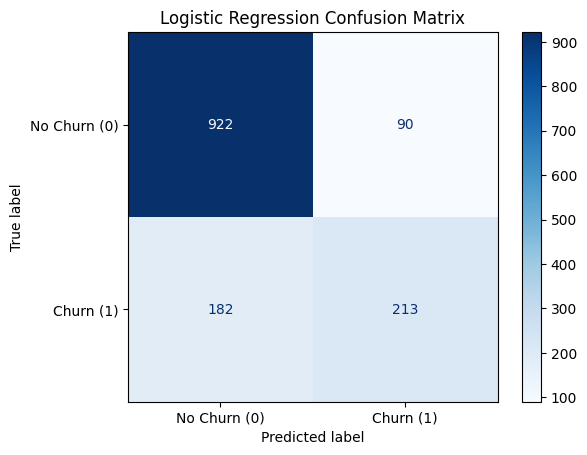

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# 2. Plot the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn (0)', 'Churn (1)'])
disp.plot(cmap=plt.cm.Blues)

# 3. Add labels and show
plt.title('Logistic Regression Confusion Matrix')
plt.show()


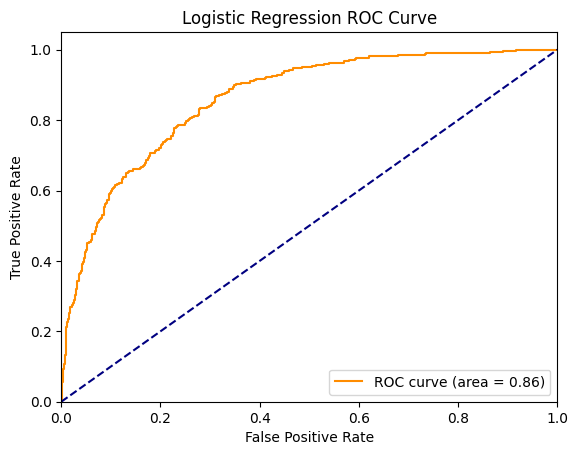

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for the positive class (1)
# Note: replace 'logistic_model' with your actual variable name
y_test_prob = log_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve details
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
roc_auc = roc_auc_score(y_test, y_test_prob)

# Plot the curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Diagonal random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [34]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
2478,0,0,0
6783,0,0,0
6125,0,1,-1
3052,0,0,0
4097,0,0,0
...,...,...,...
1728,1,0,1
5249,0,0,0
5464,0,1,-1
5851,0,0,0
